# Entropy measures: sample entropy, Renyi block entropies, permutation entropy, and transfer entropy

This notebook demonstrates the entropy tools in `nolitisea.entropy`:

| Function | Idea | Typical use |
|---|---|---|
| `sample_entropy` | SampEn: negative log of the probability that two length-`m` templates which match within tolerance `r` also match at length `m+1` (Richman & Moorman 2000, KD-tree accelerated) | A single complexity number for a scalar series |
| `renyi_entropy` | Order-`q` Renyi entropies of the box-counted phase-space partition, versus box size `eps` and embedding dimension `m` | Entropy rate `K_q`, correlation-dimension scaling, scaling-region diagnostics |
| `transfer_entropy` | Bivariate transfer entropy TE(X->Y): histogram estimate of how much the past of a *source* X predicts the future of a *target* Y beyond Y's own past (Schreiber 2000) | Directed information flow and coupling direction between two series |
| `multivariate_transfer_entropy` | Conditional transfer entropy TE(X->Y \| Z): the same estimator further conditioned on one or more extra variables Z | Removing spurious common-cause links; testing whether a direct link survives conditioning |
| `permutation_entropy` | Shannon entropy of the ordinal patterns (permutations that sort every length-`order` delay window; Bandt & Pompe 2002) | A fast, threshold-free complexity score for one or many series; deterministic order lowers it, independent noise maximises it |

Four test series with very different complexity are used throughout:

- **white noise** — independent samples, maximum complexity;
- **noisy sine** — nearly periodic, low complexity;
- **Henon map** and **Lorenz** — deterministic chaos, intermediate complexity.

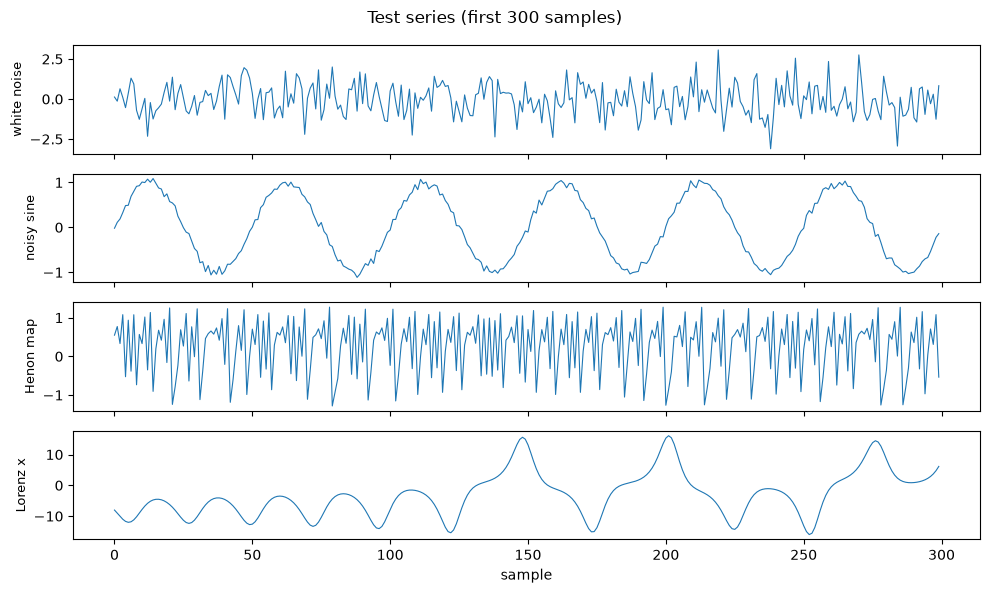

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from nolitisea.entropy.multivariate_transfer_entropy import (
    multivariate_transfer_entropy,
)
from nolitisea.entropy.permutation_entropy import permutation_entropy
from nolitisea.entropy.renyi_entropy import renyi_entropy
from nolitisea.entropy.sample_entropy import sample_entropy
from nolitisea.entropy.transfer_entropy import transfer_entropy
from nolitisea.generate.henon import henon
from nolitisea.generate.lorenz import lorenz

rng = np.random.default_rng(0)
N = 3000
t = np.arange(N)

white = rng.standard_normal(N)
sine = np.sin(2 * np.pi * t / 50.0) + 0.05 * rng.standard_normal(N)
henon_x, _ = henon(n=N, discard=2000)
_, lor = lorenz(length=N, discard=2000)
lorenz_x = lor[:, 0]

series = {
    "white noise": white,
    "noisy sine": sine,
    "Henon map": henon_x,
    "Lorenz x": lorenz_x,
}

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
for ax, (name, s) in zip(axes, series.items()):
    ax.plot(t[:300], s[:300], lw=0.8)
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel("sample")
fig.suptitle("Test series (first 300 samples)")
plt.tight_layout()
plt.show()

## 1. `sample_entropy` — SampEn

```python
sample_entropy(time_series, m=2, r_multiplier=0.2) -> float
```

- `m` — template (embedding) length; templates of length `m` and `m+1` are
  compared;
- `r_multiplier` — the Chebyshev match tolerance is `r = r_multiplier * std(x)`;
- the result is `SampEn = -ln(A / B)`, where `B` counts matching template pairs
  at length `m` and `A` at length `m+1` (self-matches excluded, pairs counted
  with `cKDTree`, so it scales to long series).

Small SampEn means self-similar / predictable (periodic or low-dimensional
deterministic), large SampEn means irregular / unpredictable. If no length-`m+1`
match is found the function returns `np.inf` (choose larger `r`, smaller `m`, or
more data).

In [2]:
print(f"{'series':14s} {'SampEn(m=2, r=0.2*std)':>22s}")
for name, s in series.items():
    se = sample_entropy(s, m=2, r_multiplier=0.2)
    print(f"{name:14s} {se:22.4f}")

series         SampEn(m=2, r=0.2*std)
white noise                    2.1869
noisy sine                     0.3915
Henon map                      0.4549
Lorenz x                       0.3414


White noise is by far the most irregular; the deterministic chaotic series and
the near-periodic sine all show much smaller SampEn.

### Sensitivity to `m` and `r_multiplier`

SampEn depends smoothly on both parameters (it is a *family* of statistics, not
a single universal number): larger `m` and smaller `r` make matching stricter,
which tends to increase SampEn until, eventually, no pairs match and the result
becomes `inf`.

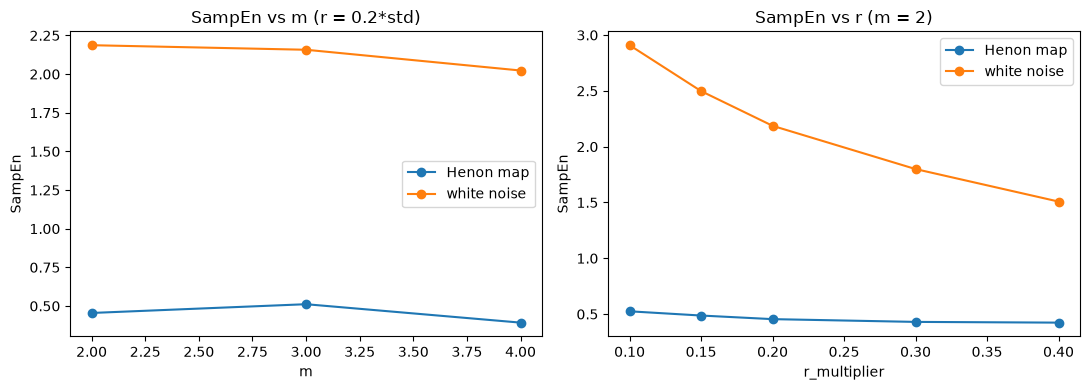

Henon  m=2..4: [0.455, 0.512, 0.392]
noise  m=2..4: [2.187, 2.157, 2.023]


In [3]:
ms = [2, 3, 4]
rs = [0.10, 0.15, 0.20, 0.30, 0.40]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: SampEn vs embedding dimension m
for name, s in [("Henon map", henon_x), ("white noise", white)]:
    vals = [sample_entropy(s, m=m, r_multiplier=0.2) for m in ms]
    axes[0].plot(ms, vals, "o-", label=name)
axes[0].set(xlabel="m", ylabel="SampEn", title="SampEn vs m (r = 0.2*std)")
axes[0].legend()

# Right: SampEn vs tolerance r
for name, s in [("Henon map", henon_x), ("white noise", white)]:
    vals = [sample_entropy(s, m=2, r_multiplier=r) for r in rs]
    axes[1].plot(rs, vals, "o-", label=name)
axes[1].set(xlabel="r_multiplier", ylabel="SampEn", title="SampEn vs r (m = 2)")
axes[1].legend()
plt.tight_layout()
plt.show()

print("Henon  m=2..4:", [round(float(sample_entropy(henon_x, m=m)), 3) for m in ms])
print("noise  m=2..4:", [round(float(sample_entropy(white, m=m)), 3) for m in ms])

In [4]:
# Edge cases:
#  * tolerance too small / dimension too high for the data amount -> no matches
#    at length m+1, and SampEn is +inf;
#  * a constant series has zero variance and gives SampEn = 0.
print("white noise, m=5, r=0.1*std:",
      sample_entropy(white, m=5, r_multiplier=0.1))
print("constant series, m=2:       ",
      sample_entropy(np.ones(500), m=2))

# Practical guidance: the canonical recommendation (Richman & Moorman 2000)
# is r between 0.1 and 0.25 *std, and comparing series with the SAME m, r and
# sampling protocol.

white noise, m=5, r=0.1*std: inf
constant series, m=2:        0.0


## 2. `renyi_entropy` — box-counting Renyi block entropies

```python
renyi_entropy(series, embed=10, delay=1, q=2.0,
              eps_min=None, eps_max=None, eps_count=20) -> dict
```

The (possibly multivariate) series is rescaled to `[0, 1]`, delay-embedded, and
covered by a uniform grid. On a geometric ladder of box sizes `eps` the
order-`q` Renyi entropy of the box occupation is computed for every prefix of
the embedding (embedding level 1 up to `embed`). `q=1` is the Shannon block
entropy; `q=2` (default) relates to the Grassberger-Procaccia correlation
entropy.

The returned dictionary contains:

- `"eps"` — box sizes in data units, shape `(eps_count,)` (descending);
- `"hq"` — block entropies, shape `(n_vars * embed, eps_count)`; row
  `e * n_vars + c` is component `c+1` at embedding level `e+1`;
- `"dhq"` — increments `hq[e] - hq[e-1]` (first row copies `hq[0]`);
- `"components"`, `"embeddings"` — row labels.

Two scalings are read from such tables:

- **entropy rate** `K_q`: in a finite data regime, the increments `dhq` settle
  to a plateau versus embedding dimension — that plateau estimates `K_q`
  (nats per sampling step); for deterministic chaos `K_2` approximates the sum
  of positive Lyapunov exponents;
- **dimension**: the slope of `hq` versus `-ln(eps)` at large embedding is
  related to the correlation dimension;
- white noise has *no* `dhq` plateau: each added embedding dimension
  contributes fresh entropy.

The smallest box sizes are limited by data amount (undersaturation), the
largest boxes by resolution: the plateau is sought in the intermediate
*scaling region*.

In [5]:
N_big = 10000
henon_big, _ = henon(n=N_big, discard=2000)
white_big = rng.standard_normal(N_big)

res = renyi_entropy(henon_big, embed=8, delay=1, q=2.0, eps_count=20)

print("keys:       ", list(res.keys()))
print("eps shape:  ", res["eps"].shape)
print("hq shape:   ", res["hq"].shape, "  (rows = n_vars*embed =", 1 * 8, ")")
print("components: ", res["components"])
print("embeddings: ", res["embeddings"])
print("eps ladder (data units), descending:")
print(np.round(res["eps"], 4))

keys:        ['eps', 'hq', 'dhq', 'components', 'embeddings']
eps shape:   (20,)
hq shape:    (8, 20)   (rows = n_vars*embed = 8 )
components:  [1 1 1 1 1 1 1 1]
embeddings:  [1 2 3 4 5 6 7 8]
eps ladder (data units), descending:
[2.5572e+00 1.2359e+00 5.9730e-01 4.1520e-01 2.8870e-01 2.0070e-01
 1.3950e-01 9.7000e-02 6.7400e-02 4.6900e-02 3.2600e-02 2.2700e-02
 1.5700e-02 1.0900e-02 7.6000e-03 5.3000e-03 3.7000e-03 2.6000e-03
 1.8000e-03 1.2000e-03]


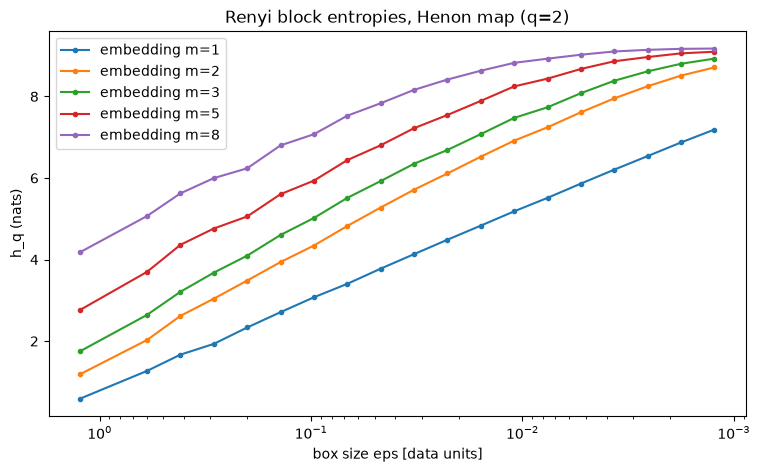

In [6]:
# Block entropy hq versus box size: in the scaling region the curves for
# successive embedding dimensions run roughly parallel (linear growth with
# -ln eps), and merge into a plateau at the coarsest boxes.
m_levels = res["embeddings"]
eps = res["eps"]

fig, ax = plt.subplots(figsize=(9, 5))
for e in [1, 2, 3, 5, 8]:
    ax.plot(eps[1:], res["hq"][e - 1, 1:], "o-", ms=3,
            label=f"embedding m={e}")
ax.set_xscale("log")
ax.set(xlabel="box size eps [data units]", ylabel="h_q (nats)",
       title="Renyi block entropies, Henon map (q=2)")
ax.legend()
plt.gca().invert_xaxis()  # fine boxes to the right
plt.show()

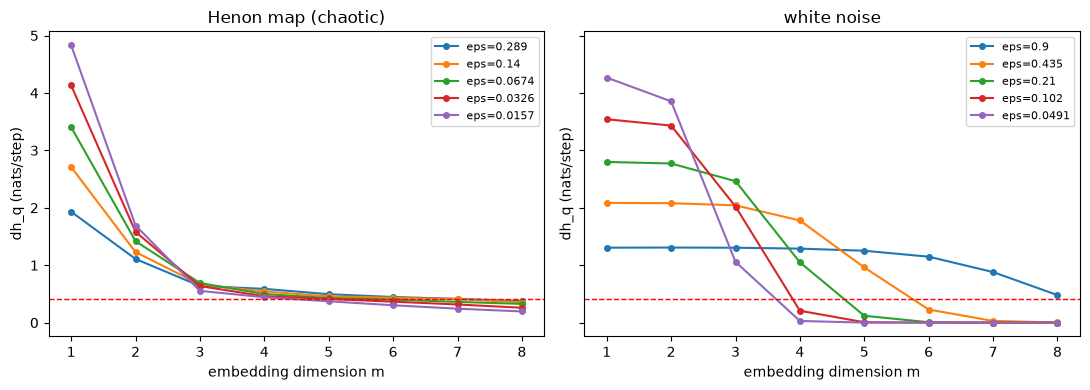

Henon K_2 estimate: 0.414 nats/iteration  (largest Lyapunov exponent: ~0.419)
White noise: the increments stay large for coarse boxes and only collapse where the data run out of neighbours -- no entropy plateau.


In [7]:
# Entropy-rate plateau: plot the increments dhq against embedding dimension
# for a few box sizes in the scaling region.  For the Henon map the increments
# settle around K_2 ~ 0.42 nats/iteration -- close to its largest Lyapunov
# exponent (lambda_1 ~ 0.419).
res_w = renyi_entropy(white_big, embed=8, delay=1, q=2.0, eps_count=20)

cols = [4, 6, 8, 10, 12]      # ladder columns in the scaling region
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, result, title in [(axes[0], res, "Henon map (chaotic)"),
                          (axes[1], res_w, "white noise")]:
    for k in cols:
        ax.plot(np.arange(1, 9), result["dhq"][:, k], "o-", ms=4,
                label=f"eps={result['eps'][k]:.3g}")
    ax.axhline(0.419, color="red", ls="--", lw=1)
    ax.set(xlabel="embedding dimension m", ylabel="dh_q (nats/step)",
           title=title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Plateau estimate: median of dhq over embedding levels 4-6 and the mid-ladder
# columns (skip both the coarse and the data-starved fine ends).
K2_henon = np.median(res["dhq"][3:6, 8:12])
print(f"Henon K_2 estimate: {K2_henon:.3f} nats/iteration  "
      f"(largest Lyapunov exponent: ~0.419)")
print("White noise: the increments stay large for coarse boxes and only "
      "collapse where the data run out of neighbours -- no entropy plateau.")

### Order `q`: Shannon (`q=1`) versus correlation (`q=2`) entropy

`q=1` computes the Shannon block entropy (`-sum p ln p`); `q=2` the
correlation-entropy variant (`-ln sum p^2`). Renyi entropies are ordered,
`H_1 >= H_2`, so the Shannon rate is an upper bound on the correlation rate.

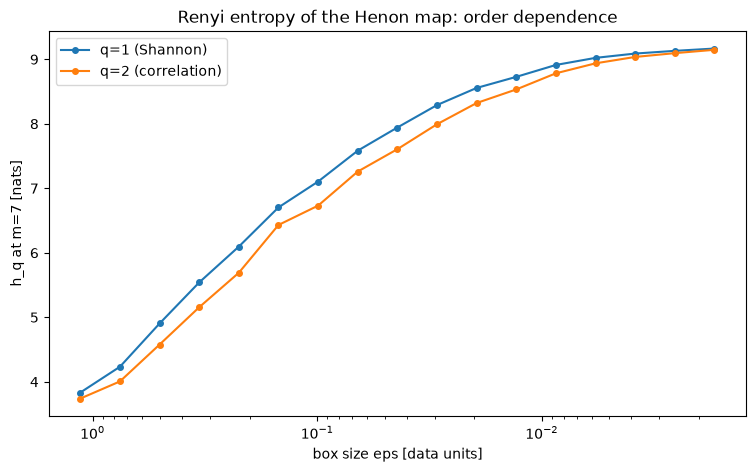

entropy-rate plateaus: K_1 = 0.456, K_2 = 0.426 nats/iteration (K_1 >= K_2 as expected)


In [8]:
res_q1 = renyi_entropy(henon_big, embed=7, delay=1, q=1.0, eps_count=18)
res_q2 = renyi_entropy(henon_big, embed=7, delay=1, q=2.0, eps_count=18)

fig, ax = plt.subplots(figsize=(9, 5))
for result, q in [(res_q1, 1), (res_q2, 2)]:
    ax.plot(result["eps"][1:], result["hq"][-1, 1:], "o-", ms=4,
            label=f"q={q} ({'Shannon' if q == 1 else 'correlation'})")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(xlabel="box size eps [data units]", ylabel="h_q at m=7 [nats]",
       title="Renyi entropy of the Henon map: order dependence")
ax.legend()
plt.show()

K1 = np.median(res_q1["dhq"][3:6, 7:11])
K2 = np.median(res_q2["dhq"][3:6, 7:11])
print(f"entropy-rate plateaus: K_1 = {K1:.3f}, K_2 = {K2:.3f} nats/iteration "
      f"(K_1 >= K_2 as expected)")

### Multivariate input

Passing a 2-D array (one column per observed component) embeds all components
in an interleaved order. Row `e * n_vars + c` of `hq` holds component `c+1` at
embedding level `e+1`; the `"components"` and `"embeddings"` arrays label every
row.

hq shape: (6, 15)  (n_vars*embed = 2*3)
components : [1 2 1 2 1 2]
embeddings : [1 1 2 2 3 3]


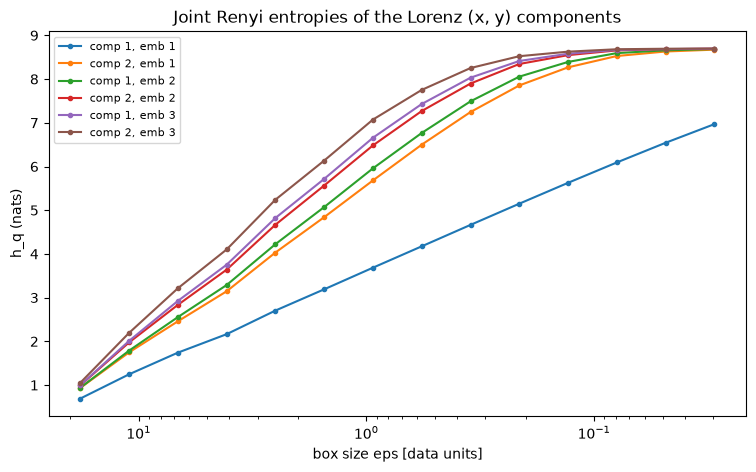

In [9]:
# Observe the x and y coordinates of the Lorenz flow simultaneously.
_, lor_big = lorenz(length=6000, discard=2000)

res_mv = renyi_entropy(lor_big[:, :2], embed=3, delay=1, q=2.0, eps_count=15)
print("hq shape:", res_mv["hq"].shape, " (n_vars*embed = 2*3)")
print("components :", res_mv["components"])
print("embeddings :", res_mv["embeddings"])

fig, ax = plt.subplots(figsize=(9, 5))
for row in range(res_mv["hq"].shape[0]):
    ax.plot(res_mv["eps"][1:], res_mv["hq"][row, 1:], "o-", ms=3,
            label=f"comp {res_mv['components'][row]}, "
                  f"emb {res_mv['embeddings'][row]}")
ax.set_xscale("log")
ax.invert_xaxis()
ax.set(xlabel="box size eps [data units]", ylabel="h_q (nats)",
       title="Joint Renyi entropies of the Lorenz (x, y) components")
ax.legend(fontsize=8)
plt.show()

## 3. `transfer_entropy` — directed information flow

```python
transfer_entropy(source, target, k=1, l=1, h=1, bins=10) -> float
```

Transfer entropy (Schreiber 2000) measures how much the past of a *source*
series X reduces uncertainty about the future of a *target* series Y, beyond
what Y's own past already explains:

    TE_{X->Y} = I(Y_{t+h} ; X history  |  Y history)

It is asymmetric — `TE(X->Y)` and `TE(Y->X)` are different quantities — so it
detects the *direction* of information flow. The result is in bits, estimated
by equi-width histogram binning:

- `k` — history length of the target (how many past Y values are conditioned on);
- `l` — history length of the source (how many past X values are used);
- `h` — prediction horizon in samples;
- `bins` — number of equi-width bins per scalar variable.

The plug-in estimate is non-negative and gives ~0 for independent series; like
all histogram statistics it carries a small finite-sample upward bias, so long
series give sharper results.


TE(X -> Y) coupled : 0.2344 bits
TE(Y -> X) coupled : 0.0160 bits
TE(indep. series)  : 0.0248 bits
directionality ratio TE(X->Y) / TE(Y->X) = 14.6


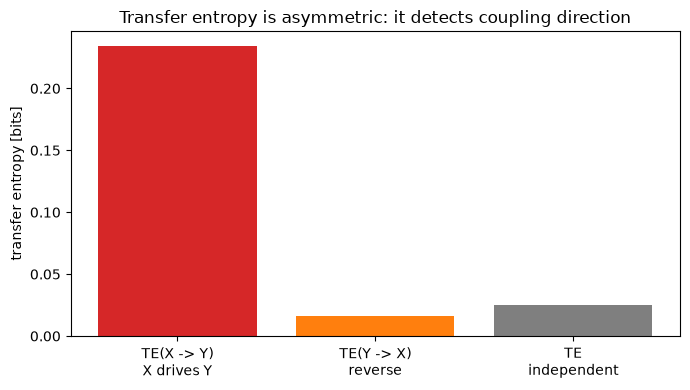

In [10]:
# Coupled AR(1): X is autonomous, Y is driven by its own past AND by X.
rng_te = np.random.default_rng(0)
n_te = 8000
x_drive = np.zeros(n_te)
y_drive = np.zeros(n_te)
for t in range(n_te - 1):
    x_drive[t + 1] = 0.8 * x_drive[t] + 0.2 * rng_te.standard_normal()
    y_drive[t + 1] = (0.5 * y_drive[t] + 0.5 * x_drive[t]
                      + 0.2 * rng_te.standard_normal())
x_null = rng_te.standard_normal(n_te)
y_null = rng_te.standard_normal(n_te)

te_forward = transfer_entropy(x_drive, y_drive, bins=8)   # X -> Y
te_reverse = transfer_entropy(y_drive, x_drive, bins=8)   # Y -> X
te_indep = transfer_entropy(x_null, y_null, bins=8)       # null case

print(f"TE(X -> Y) coupled : {te_forward:.4f} bits")
print(f"TE(Y -> X) coupled : {te_reverse:.4f} bits")
print(f"TE(indep. series)  : {te_indep:.4f} bits")
print(f"directionality ratio TE(X->Y) / TE(Y->X) = {te_forward / te_reverse:.1f}")

fig, ax = plt.subplots(figsize=(7, 4))
labels = ["TE(X -> Y)\nX drives Y", "TE(Y -> X)\nreverse",
          "TE\nindependent"]
ax.bar(labels, [te_forward, te_reverse, te_indep],
       color=["tab:red", "tab:orange", "tab:gray"])
ax.set_ylabel("transfer entropy [bits]")
ax.set_title("Transfer entropy is asymmetric: it detects coupling direction")
plt.tight_layout()
plt.show()


### Prediction horizon `h`: coupling lag and information decay

`h` sets how far ahead the target's future is read. Sweeping `h` reveals the
*coupling lag*: information from X is strongest at the horizon where Y actually
responds, and fades for longer horizons as predictability is lost to the
systems' own dynamics.


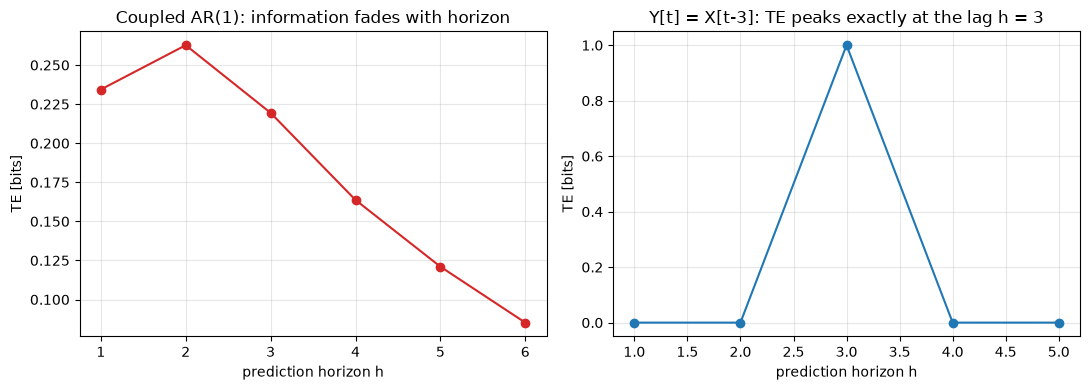

AR(1) TE vs h      : [0.234 0.263 0.219 0.164 0.121 0.085]
delayed copy TE vs h: [0. 0. 1. 0. 0.]


In [11]:
hs = np.arange(1, 7)
te_vs_h = [transfer_entropy(x_drive, y_drive, h=int(h), bins=8) for h in hs]

# A sharply tuned system: Y[t] = X[t-3] with X iid fair binary bits.
rng_lag = np.random.default_rng(1)
n_lag = 20000
x_bits = rng_lag.integers(0, 2, n_lag).astype(np.float64)
y_bits = np.empty(n_lag)
y_bits[:3] = rng_lag.integers(0, 2, 3)
y_bits[3:] = x_bits[:-3]               # Y copies X with a 3-step delay
hs_lag = np.arange(1, 6)
te_lag = [transfer_entropy(x_bits, y_bits, h=int(h), bins=2)
          for h in hs_lag]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hs, te_vs_h, "o-", color="tab:red")
axes[0].set(xlabel="prediction horizon h", ylabel="TE [bits]",
            title="Coupled AR(1): information fades with horizon")
axes[1].plot(hs_lag, te_lag, "o-", color="tab:blue")
axes[1].set(xlabel="prediction horizon h", ylabel="TE [bits]",
            title="Y[t] = X[t-3]: TE peaks exactly at the lag h = 3")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("AR(1) TE vs h      :", np.round(te_vs_h, 3))
print("delayed copy TE vs h:", np.round(te_lag, 3))


### Source history length `l`

`l` controls how many past source values enter the estimate. If Y responds to
an *older* source value, `l = 1` (only the current source value) misses the
drive while a longer history recovers it. Below, Y[t+1] depends on X[t-1] but
not on X[t] (X is white noise): TE is ~0 with `l = 1` and ~1.3 bits with
`l >= 2`.


In [12]:
rng_l = np.random.default_rng(2)
n_l = 20000
x_hist_demo = rng_l.standard_normal(n_l)
y_hist_demo = np.zeros(n_l)
for t in range(n_l - 1):
    y_hist_demo[t + 1] = (0.3 * y_hist_demo[t] + 0.7 * x_hist_demo[t - 1]
                          + 0.1 * rng_l.standard_normal())

for ell in (1, 2, 3):
    te_ell = transfer_entropy(x_hist_demo, y_hist_demo, l=ell, bins=8)
    print(f"TE(X -> Y), l={ell}: {te_ell:.4f} bits")
print("-> l=1 sees only the irrelevant X[t]; l >= 2 includes the driving "
      "X[t-1].")


TE(X -> Y), l=1: 0.0108 bits
TE(X -> Y), l=2: 1.2909 bits
TE(X -> Y), l=3: 1.3131 bits
-> l=1 sees only the irrelevant X[t]; l >= 2 includes the driving X[t-1].


## 4. `multivariate_transfer_entropy` — conditional transfer entropy

```python
multivariate_transfer_entropy(source, target, condition,
                              k=1, l=1, l_z=1, h=1, bins=10) -> float
```

The *conditional* transfer entropy further conditions on one or more extra
system variables Z:

    TE_{X->Y | Z} = I(Y_{t+h} ; X history  |  Y history, Z history)

This isolates the genuine X -> Y link from spurious flow created by a *common
driver* Z that influences both X and Y: conditioning on Z removes the spurious
link, while a real direct link survives it.

- `condition` — a single 1-D array, a list of 1-D arrays, or a 2-D array of
  shape `(n_cond, n_samples)`;
- `l_z` — history length of the conditioning variables: one int applied to
  all, or a sequence with one entry per variable.


Common cause Z -> X, Z -> Y (no real X -> Y link):
  TE(X -> Y)     = 0.0403 bits  (spurious)
  TE(X -> Y | Z) = 0.0053 bits  (removed by conditioning)
Direct link X -> Y with independent Z -> Y:
  TE(X -> Y)     = 0.5836 bits
  TE(X -> Y | Z) = 0.8561 bits  (link survives)


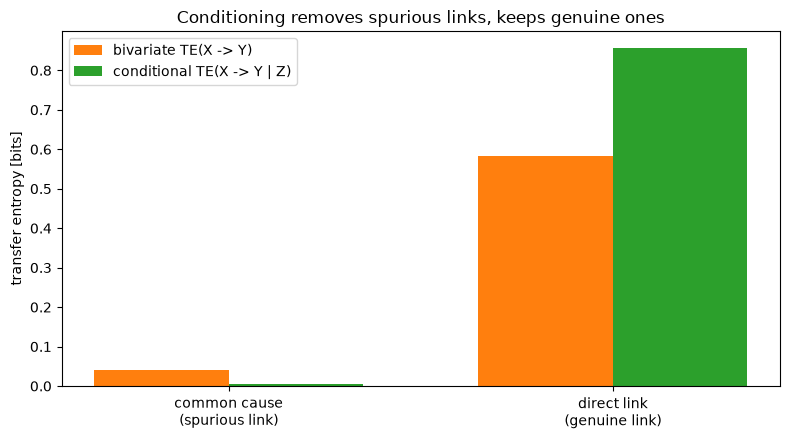

In [13]:
rng_c = np.random.default_rng(3)
n_c = 8000

# Scenario A: common cause. Z is strongly autocorrelated and drives BOTH
# X and Y; X itself has no effect on Y.
z_common = np.zeros(n_c)
x_common = np.zeros(n_c)
y_common = np.zeros(n_c)
z_common[0] = rng_c.standard_normal()
for t in range(n_c - 1):
    z_common[t + 1] = 0.95 * z_common[t] + 0.1 * rng_c.standard_normal()
    x_common[t + 1] = z_common[t] + 0.02 * rng_c.standard_normal()
    y_common[t + 1] = z_common[t] + 0.02 * rng_c.standard_normal()

te_biv_common = transfer_entropy(x_common, y_common, bins=8)
te_cond_common = multivariate_transfer_entropy(
    x_common, y_common, z_common, bins=8
)

# Scenario B: direct link. X drives Y directly; Z is an independent second
# driver of Y.
x_direct = rng_c.standard_normal(n_c)
z_direct = rng_c.standard_normal(n_c)
y_direct = np.zeros(n_c)
for t in range(n_c - 1):
    y_direct[t + 1] = (0.5 * y_direct[t] + 0.5 * x_direct[t]
                       + 0.3 * z_direct[t] + 0.2 * rng_c.standard_normal())

te_biv_direct = transfer_entropy(x_direct, y_direct, bins=8)
te_cond_direct = multivariate_transfer_entropy(
    x_direct, y_direct, z_direct, bins=8
)

print("Common cause Z -> X, Z -> Y (no real X -> Y link):")
print(f"  TE(X -> Y)     = {te_biv_common:.4f} bits  (spurious)")
print(f"  TE(X -> Y | Z) = {te_cond_common:.4f} bits  (removed by "
      "conditioning)")
print("Direct link X -> Y with independent Z -> Y:")
print(f"  TE(X -> Y)     = {te_biv_direct:.4f} bits")
print(f"  TE(X -> Y | Z) = {te_cond_direct:.4f} bits  (link survives)")

fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(2)
width = 0.35
ax.bar(x_pos - width / 2, [te_biv_common, te_biv_direct], width,
       label="bivariate TE(X -> Y)", color="tab:orange")
ax.bar(x_pos + width / 2, [te_cond_common, te_cond_direct], width,
       label="conditional TE(X -> Y | Z)", color="tab:green")
ax.set_xticks(x_pos)
ax.set_xticklabels(["common cause\n(spurious link)",
                    "direct link\n(genuine link)"])
ax.set_ylabel("transfer entropy [bits]")
ax.set_title("Conditioning removes spurious links, keeps genuine ones")
ax.legend()
plt.tight_layout()
plt.show()


### Multiple conditioning variables

Pass a list of arrays (or a 2-D array of shape `(n_cond, n_samples)`) to
condition on several variables at once; `l_z` may be a per-variable sequence.
Below, Y is driven by Z1 and Z2 but not by the independent X: conditioning on
both leaves TE near zero. The list and 2-D forms give identical results.


In [14]:
z1 = rng_c.standard_normal(n_c)
z2 = rng_c.standard_normal(n_c)
y_multi = np.zeros(n_c)
for t in range(n_c - 1):
    y_multi[t + 1] = (0.4 * y_multi[t] + 0.3 * z1[t] + 0.3 * z2[t]
                      + 0.2 * rng_c.standard_normal())

te_uncond = transfer_entropy(x_direct, y_multi, bins=6)
te_list = multivariate_transfer_entropy(x_direct, y_multi, [z1, z2], bins=6)
te_2d = multivariate_transfer_entropy(
    x_direct, y_multi, np.vstack([z1, z2]), bins=6
)
print(f"TE(X -> Y)          : {te_uncond:.4f} bits")
print(f"TE(X -> Y | Z1, Z2) : {te_list:.4f} bits  (list input)")
print(f"TE(X -> Y | Z1, Z2) : {te_2d:.4f} bits  (2-D array input)")
print("X is unrelated to Y: all estimates stay near zero.")


TE(X -> Y)          : 0.0113 bits
TE(X -> Y | Z1, Z2) : 0.0522 bits  (list input)
TE(X -> Y | Z1, Z2) : 0.0522 bits  (2-D array input)
X is unrelated to Y: all estimates stay near zero.


## 5. `permutation_entropy` — ordinal-pattern complexity

```python
permutation_entropy(series, order=3, delay=1, normalize=True) -> np.ndarray
```

Each length-`order` window (coordinates sampled every `delay` samples) is
replaced by its *ordinal pattern* — the permutation that sorts the window
values.  The permutation entropy is the Shannon entropy of the empirical
frequencies of the `order!` possible patterns (Bandt & Pompe 2002).  A series
that always rises in the same way uses a single pattern and scores 0;
independent samples visit every pattern equally often and score the maximum.

- `order` — window length `m`; there are `m!` patterns, so larger `order`
  needs enough data (`N >> m!` windows) to estimate frequencies;
- `delay` — lag between consecutive window coordinates;
- `normalize` — divide by `ln(m!)` so the result lies in `[0, 1]` (default);
  set to False to obtain the entropy in nats;
- 1-D input returns an array of shape `(1,)`; a 2-D array of shape
  `(n_samples, n_series)` returns one value per column.

Tied values inside a window are ordered by their time of appearance (the
earlier position gets the smaller rank); a constant or monotone series
contains a single pattern and therefore has permutation entropy zero.

series        PE(order=3)
white noise        0.9997
noisy sine         0.8308
Henon map          0.8820
Lorenz x           0.5406


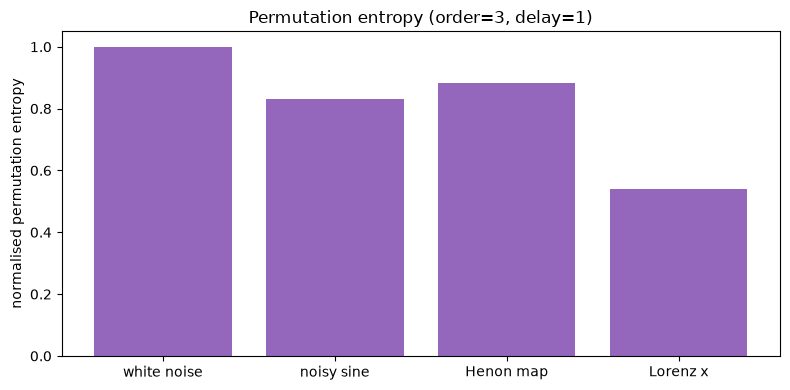

In [15]:
# Default settings: order=3 (6 patterns), delay=1, normalised to [0, 1].
names = list(series)
pe_values = [
    float(permutation_entropy(s, order=3)[0]) for s in series.values()
]

print(f"{'series':12s} {'PE(order=3)':>12s}")
for name, value in zip(names, pe_values):
    print(f"{name:12s} {value:12.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(names, pe_values, color="tab:purple")
ax.set_ylim(0, 1.05)
ax.set_ylabel("normalised permutation entropy")
ax.set_title("Permutation entropy (order=3, delay=1)")
plt.tight_layout()
plt.show()

### Embedding order `order`

With larger `order` the number of patterns grows as `m!`.  White noise keeps
filling all of them almost uniformly, whereas a deterministic flow uses only a
small subset, so the normalised entropy of chaotic/periodic series drops as
`order` reveals their temporal structure.  The window count must stay well
above `m!`: here `N = 3000`, enough up to `order = 6` (`6! = 720`).

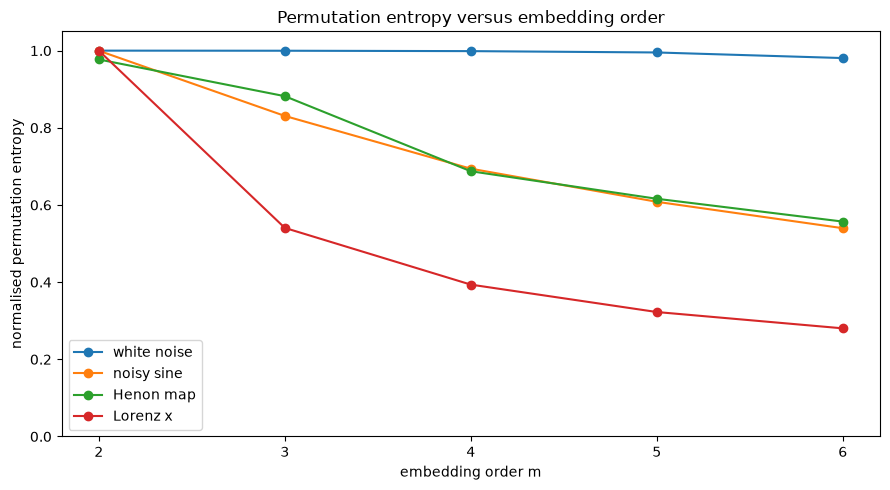

normalised PE:
series      m=2    m=3    m=4    m=5    m=6    
white noise 1.000   1.000   0.999   0.995   0.981   
noisy sine  1.000   0.831   0.694   0.608   0.540   
Henon map   0.977   0.882   0.687   0.616   0.557   
Lorenz x    1.000   0.541   0.394   0.323   0.280   
patterns m!  :2       6       24      120     720     


In [16]:
orders = np.arange(2, 7)
pe_vs_order = {
    name: [float(permutation_entropy(s, order=m)[0]) for m in orders]
    for name, s in series.items()
}

fig, ax = plt.subplots(figsize=(9, 5))
for name, values in pe_vs_order.items():
    ax.plot(orders, values, marker="o", label=name)
ax.set_xlabel("embedding order m")
ax.set_ylabel("normalised permutation entropy")
ax.set_ylim(0, 1.05)
ax.set_xticks(orders)
ax.set_title("Permutation entropy versus embedding order")
ax.legend()
plt.tight_layout()
plt.show()

print("normalised PE:")
header = f"{'series':12s}" + "".join(f"m={m:<5d}" for m in orders)
print(header)
for name, values in pe_vs_order.items():
    print(f"{name:12s}" + "".join(f"{v:<8.3f}" for v in values))
print("patterns m!  :" + "".join(f"{math.factorial(m):<8d}" for m in orders))

### Time delay `delay`

`delay` controls how far apart the coordinates of a window are.  At `delay = 1`
a smooth deterministic flow shows repeated up/down motifs (low PE).  As the
delay grows, coordinates decorrelate and their ranks become unpredictable, so
the PE of every series approaches 1.  For the noisy sine, a delay equal to its
period (50 samples) puts every coordinate at the same phase; the tiny additive
noise then decides the ranks, and the PE jumps to the white-noise ceiling.  In
practice the delay is chosen from the autocorrelation or mutual information,
just as for delay embeddings.

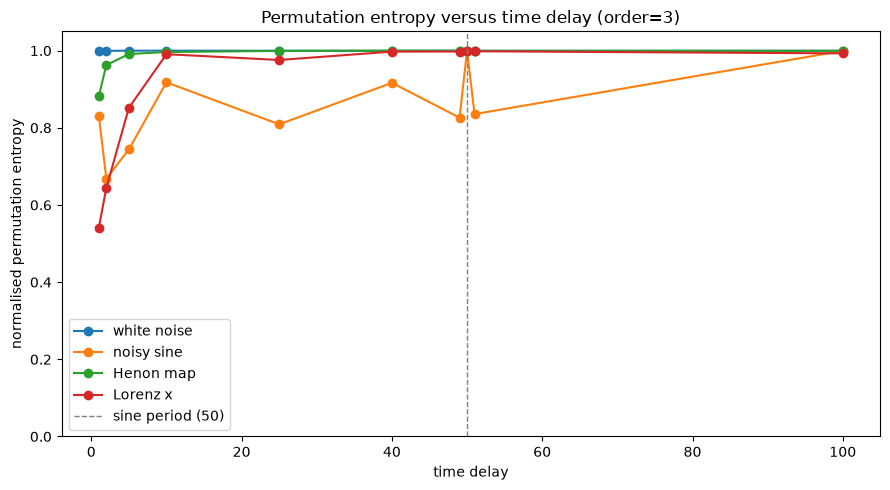

normalised PE:
series      d=1    d=2    d=5    d=10   d=25   d=40   d=49   d=50   d=51   d=100  
white noise 1.000   0.999   1.000   1.000   1.000   0.999   1.000   1.000   1.000   1.000   
noisy sine  0.831   0.668   0.744   0.918   0.809   0.917   0.826   0.999   0.836   0.999   
Henon map   0.882   0.963   0.991   0.996   0.999   1.000   0.999   1.000   0.999   0.999   
Lorenz x    0.541   0.644   0.852   0.991   0.976   0.997   0.998   0.998   0.998   0.993   


In [17]:
delays = np.array([1, 2, 5, 10, 25, 40, 49, 50, 51, 100])

fig, ax = plt.subplots(figsize=(9, 5))
for name, s in series.items():
    values = [
        float(permutation_entropy(s, order=3, delay=int(d))[0])
        for d in delays
    ]
    ax.plot(delays, values, marker="o", label=name)
ax.axvline(50, color="gray", ls="--", lw=1, label="sine period (50)")
ax.set_xlabel("time delay")
ax.set_ylabel("normalised permutation entropy")
ax.set_ylim(0, 1.05)
ax.set_title("Permutation entropy versus time delay (order=3)")
ax.legend()
plt.tight_layout()
plt.show()

print("normalised PE:")
print(f"{'series':12s}" + "".join(f"d={d:<5d}" for d in delays))
for name, s in series.items():
    values = [
        float(permutation_entropy(s, order=3, delay=int(d))[0])
        for d in delays
    ]
    print(f"{name:12s}" + "".join(f"{v:<8.3f}" for v in values))

### Raw entropy, ties, and multivariate input

With `normalize=False` the result is the Shannon entropy in nats, bounded by
`ln(m!)`.  Ties are resolved by time of appearance, so constant and monotone
series give exactly zero.  A 2-D array is evaluated column by column in one
call, which is identical to calling the function on each column separately.

In [18]:
# Raw Shannon entropy in nats, bounded by ln(m!); white noise nearly saturates it.
for m in (3, 5):
    raw = float(permutation_entropy(white, order=m, normalize=False)[0])
    print(f"white noise, order={m}: {raw:.4f} nats; upper bound ln(m!) = "
          f"{np.log(math.factorial(m)):.4f}")

# Fully predictable series use a single pattern -> entropy zero.
print("constant series :", permutation_entropy(np.full(500, 1.0), order=3))
print("monotone series :", permutation_entropy(np.arange(500.0), order=3))

# A 2-D array evaluates all columns at once.
batch = np.column_stack(list(series.values()))
pe_batch = permutation_entropy(batch, order=3)
pe_separate = np.array([
    float(permutation_entropy(s, order=3)[0]) for s in series.values()
])
print("batch input :", np.round(pe_batch, 6))
print("1-D calls   :", np.round(pe_separate, 6))
print("max abs diff:", float(np.max(np.abs(pe_batch - pe_separate))))

white noise, order=3: 1.7913 nats; upper bound ln(m!) = 1.7918
white noise, order=5: 4.7647 nats; upper bound ln(m!) = 4.7875
constant series : [0.]
monotone series : [0.]
batch input : [0.999722 0.830792 0.881957 0.540585]
1-D calls   : [0.999722 0.830792 0.881957 0.540585]
max abs diff: 0.0


## Summary

- **`sample_entropy(x, m, r_multiplier)`** returns one complexity number:
  `-ln(A/B)` for length-`m`/`m+1` template matches within Chebyshev tolerance
  `r = r_multiplier * std(x)`. White noise scores highest, periodic and
  chaotic deterministic series much lower; use the same `m`/`r` when comparing
  series, and expect `inf` when matching is too strict for the data amount.
- **`renyi_entropy(series, embed, delay, q, eps_count, ...)`** returns a dict
  with the block-entropy table `"hq"` over box size (geometric ladder, `"eps"`)
  and embedding level, its increments `"dhq"`, and per-row component/embedding
  labels. For chaotic data the increments plateau at the entropy rate `K_q`
  (Henon: ~0.42 nats/step, matching its largest Lyapunov exponent); for white
  noise no plateau exists. `q=1` gives the Shannon rate, `q=2` the
  correlation rate (`K_1 >= K_2`); 2-D input produces interleaved multivariate
  embeddings.
- **`transfer_entropy(source, target, k, l, h, bins)`** estimates the directed
  information flow TE(X->Y) in bits with equi-width histograms. It is
  asymmetric: on a coupled AR(1) the forward TE (~0.23 bits) is ~15x the
  reverse, while independent series give ~0. Sweeping `h` locates the coupling
  lag (a delayed copy Y[t] = X[t-3] peaks sharply at h = 3) and shows the
  information fading at longer horizons; increasing `l` recovers drives that
  act through older source values.
- **`multivariate_transfer_entropy(source, target, condition, ...)`**
  estimates the conditional TE(X->Y | Z). Conditioning on a common driver Z
  collapses the spurious link (to ~0.005 bits) while a genuine direct link
  stays large (~0.9 bits). Several conditioning variables are accepted as a
  list of arrays or as a 2-D array (identical results), with per-variable
  history lengths via `l_z`.
- **`permutation_entropy(series, order, delay, normalize)`** counts the ordinal patterns (permutations sorting each length-`order` delay window) and returns their Shannon entropy, normalised by `ln(m!)` to `[0, 1]`; 1-D input gives shape `(1,)`, a 2-D array one value per column, and `normalize=False` gives nats. At order 3 white noise scores ~1.00 while the deterministic series stay lower (Lorenz ~0.54, Henon ~0.88, noisy sine ~0.83). Raising the order separates structure from noise: Lorenz falls from 0.54 to 0.28 between order 3 and 6 whereas white noise stays at ~0.98 (`m!` reaches 720 patterns). Growing the delay decorrelates the window coordinates and pushes every series toward 1; the noisy sine jumps to 0.999 at its period (delay 50) because only the additive noise breaks the tie. Raw white-noise entropy nearly saturates the bound (4.7647 of 4.7875 nats at order 5), constant/monotone series give exactly 0, and batch 2-D calls match separate 1-D calls to 0.0 difference.
